In [1]:
# !pip install openai-whisper transformers datasets torchaudio jiwer scikit-learn seaborn matplotlib accelerate

In [2]:
# 2. data loading and babble

import torch
import random
import numpy as np
from datasets import load_dataset


slurp_dataset = load_dataset("qmeeus/slurp", split="train", streaming=True)
dataset_iterator = iter(slurp_dataset)

valid_commands = []
babble_pool = []
seen_slurp_ids = set()

#  collect commands and build the babble pool in one loop
while len(valid_commands) < 100:
    try:
        row = next(dataset_iterator)

        audio_array = row['audio']['array']
        babble_pool.append(audio_array)

        slurp_id = row['slurp_id']
        if slurp_id in seen_slurp_ids:
            continue

        sentence = row['sentence']
        if len(sentence.split()) < 4:
            continue

        valid_commands.append(row)
        seen_slurp_ids.add(slurp_id)

    except StopIteration:
        break
print(f"collected {len(valid_commands)} valid commands and {len(babble_pool)} babble samples")


# return an array/narray of floats
def synthesize_noisy_audio(clean_audio, babble_pool, snr_db):
    #
    # 1. sample 3 random audios from the pool to create babble;
    # 2. trim to to the same length;
    # 3. mix
    #
    if snr_db == "clean":
        return clean_audio

    assert len(babble_pool) >= 3

    background_audios = random.sample(babble_pool, 3)
    mixed_babble = torch.zeros(len(clean_audio), dtype=torch.float32)

    for b in background_audios:
        babble = []
        if len(b) < len(clean_audio):
            # pad 0 elements at the beginning, len(clean_audio)
            # elements at the end in "wrap" mode
            babble = np.pad(b, (0, len(clean_audio) - len(b)), 'wrap')
        else:
            babble = b[:len(clean_audio)]

        mixed_babble += torch.tensor(babble, dtype=torch.float32)

    # normalize
    mixed_babble /= len(background_audios)

    # calculate signal power
    clean_tensor = torch.tensor(clean_audio, dtype=torch.float32)
    clean_power = torch.mean(clean_tensor ** 2)
    babble_power = torch.mean(mixed_babble ** 2)

    # scale babble to reach target SNR
    # SNR = 10*log10(clean_power/babble_power)
    # -> babble_power = clean_power / (10 ** (SNR/10))
    target_babble_power = clean_power / (10 ** (snr_db / 10))

    # power = sum(s**2 for s in signal)
    # -> power scaling factor is square of signal scaling factor
    scaling_factor = torch.sqrt(target_babble_power / babble_power + 1e-8)

    clean_tensor = torch.tensor(clean_audio, dtype=torch.float32) # Define clean_tensor
    noisy_audio = clean_tensor + scaling_factor * mixed_babble
    return noisy_audio.numpy()

# build the eval dataset
snr_levels = ["clean", 10, 5, 0]
eval_dataset = []

for row in valid_commands:
    clean_audio = row['audio']['array']
    item = {
        'ground_truth': row['sentence'],
        'audio_variants': {snr: synthesize_noisy_audio(clean_audio, babble_pool, snr) for snr in snr_levels}
    }
    eval_dataset.append(item)

print("eval dataset generated")

collected 100 valid commands and 595 babble samples
eval dataset generated


In [3]:
# 2.5 listen to the synthesized audio

import IPython.display as ipd

sample_row = valid_commands[0]
clean_audio = sample_row['audio']['array']
sampling_rate = sample_row['audio']['sampling_rate']
ground_truth_text = sample_row['sentence']

print(f"Ground Truth: '{ground_truth_text}")
print("-" * 30)

print("\n1. Clean Audio (Baseline):")
ipd.display(ipd.Audio(clean_audio, rate=sampling_rate))

print(f"\n2. Noisy Audio (SNR = 10dB):")
audio_5db = synthesize_noisy_audio(clean_audio, babble_pool, 10)
ipd.display(ipd.Audio(audio_5db, rate=sampling_rate))

print(f"\n2. Noisy Audio (SNR = 5dB):")
audio_5db = synthesize_noisy_audio(clean_audio, babble_pool, 5)
ipd.display(ipd.Audio(audio_5db, rate=sampling_rate))

print(f"\n3. Noisy Audio (SNR = 0dB):")
audio_0db = synthesize_noisy_audio(clean_audio, babble_pool, 0)
ipd.display(ipd.Audio(audio_0db, rate=sampling_rate))

Ground Truth: 'i need an event three days from now scheduled with amy
------------------------------

1. Clean Audio (Baseline):



2. Noisy Audio (SNR = 10dB):



2. Noisy Audio (SNR = 5dB):



3. Noisy Audio (SNR = 0dB):


In [12]:
# 3. inference & alignment function

import jiwer
from whisper.normalizers import EnglishTextNormalizer
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import whisper
from pprint import pprint

device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else device
print(f"device: {device}")
normalizer = EnglishTextNormalizer()

# output: [(conf, is_correct)], e.g. [(.8, 1), (.3, 0)]
def align_and_label(words_conf, ground_truth):
    #
    # 1. run Jiwer's alignment on hypotthesis and refernece sentences
    # 2. assign label of the words within chunks based on chunk.type
    #  ('equal', 'insert', 'substitute') == 'equal'
    #
    ref = normalizer(ground_truth).strip()

    # normalize hypothesis word by word
    cleaned_words_conf = []
    for word, conf in words_conf:
        clean_word = normalizer(word).strip()

        if clean_word:
            for sub_word in clean_word.split():
                cleaned_words_conf.append((sub_word, conf))

    hypothesis = " ".join([w for w, _ in cleaned_words_conf])

    if not hypothesis:
        print(f"  [!] Total failure. Ground truth: '{ground_truth}'")
        pprint(f"            asr tanscribe result: {words_conf}")
        return []

    # use jiwer's alignment.alignments
    out = jiwer.process_words(ref, hypothesis)
    confidences_and_labels = []

    for chunk in out.alignments[0]:
        # if the chunk is a match, all words in this chunk are correct
        if chunk.type == 'equal':
            for i in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                confidences_and_labels.append((cleaned_words_conf[i][1], 1))

        # if the chunk is a insert or substitute, those words are wrong
        elif chunk.type in ['insert', 'substitute']:
            for i in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                confidences_and_labels.append((cleaned_words_conf[i][1], 0))

        # ignore 'delete' chunk because the model didn't output a word to assign a confidence to
    return confidences_and_labels

# output: [(conf, is_correct)], e.g. [(.8, 1), (.3, 0)]
def get_whisper_word_confidences_bk(model, audio_array, ground_truth):
    # Ensure audio is float32, which transcribe() expects
    audio_array = np.array(audio_array, dtype=np.float32)

    # Use transcribe() with word_timestamps=True to natively extract word probabilities
    result = model.transcribe(
        audio_array,
        language="en",
        word_timestamps=True,
        condition_on_previous_text=False # Prevents hallucinations across separate commands
    )

    words_conf = []

    # Safely extract the generated words and their confidences
    for segment in result.get("segments", []):
        for word_info in segment.get("words", []):
            word_text = word_info["word"].strip()
            # Whisper's word 'probability' is a float between 0.0 and 1.0
            word_prob = word_info["probability"]

            # Filter out empty strings that sometimes occur with special characters
            if word_text:
                words_conf.append((word_text, word_prob))

    if not words_conf:
        print(f"  [!] Total failure. Ground truth: '{ground_truth}'")
        pprint(f"            asr tanscribe result: {result}")
        return []
    return align_and_label(words_conf, ground_truth)


# output: [(conf, is_correct)], e.g. [(.8, 1), (.3, 0)]
def get_whisper_word_confidences(model, processor, audio_array, ground_truth):
    tokenizer = processor.tokenizer

    if not isinstance(audio_array, torch.Tensor):
        audio_array = torch.tensor(audio_array).float()

    # extract the Mel spectrogram features.
    inputs = processor(
        audio=audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    ).to(model.device)

    # FIX: Ensure both device AND dtype match the model's parameters
    inputs = {
        k: v.to(model.device, dtype=model.dtype) if v.is_floating_point() else v.to(model.device) 
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,
            num_beams=1
        )

    # Calculate transition scores for the generated tokens
    transition_scores = model.compute_transition_scores(
        outputs.sequences,
        outputs.scores,
        normalize_logits=True
    )

    # Whisper's output sequences start with special decoder tokens 
    # (e.g., <|startoftranscript|>, <|en|>, <|transcribe|>, <|notimestamps|>).
    # outputs.scores only contains the logits for the newly generated words.
    # We slice outputs.sequences from the end to match the length of transition_scores.
    num_generated_tokens = len(transition_scores[0])
    generated_tokens = outputs.sequences[0, -num_generated_tokens:]

    words_conf = []
    current_word = ""
    current_word_probs = []

    for token, score in zip(generated_tokens, transition_scores[0]):
        # Skip special tokens (timestamps, language tags, etc.)
        if token.item() in tokenizer.all_special_ids:
            continue

        token_str = processor.decode(token, clean_up_tokenization_spaces=False)
        prob = torch.exp(score).item()

        # Handle BPE token spacing
        clean_token = token_str.replace('Ġ', ' ')

        if clean_token.startswith(" ") and current_word:
            # Start of a new word: append the previous word and its minimum subword probability
            words_conf.append((current_word.strip(), min(current_word_probs)))

            # Reset for the new word
            current_word = clean_token
            current_word_probs = [prob]
        else:
            # Continuation of the current word
            current_word += clean_token
            current_word_probs.append(prob)

    # Handle the final word in the sequence
    if current_word.strip():
        words_conf.append((current_word.strip(), min(current_word_probs)))

    if not words_conf:
        print(f"  [!] Total failure. Ground truth: '{ground_truth}'")
        pprint(f"            asr transcribe result: {processor.decode(outputs.sequences[0])}")
        return []
        
    # Assuming align_and_label is defined elsewhere in your code
    return align_and_label(words_conf, ground_truth)


# output: [(conf, is_correct)], e.g. [(.8, 1), (.3, 0)]
def get_granite_word_confidences(model, processor, audio_array, ground_truth):
    tokenizer = processor.tokenizer

    user_prompt = "<|audio|>can you transcribe the speech into a written format?"
    chat = [{"role": "user", "content": user_prompt}]
    prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)

    if not isinstance(audio_array, torch.Tensor):
        audio_array = torch.tensor(audio_array).float()

    inputs = processor(
        text=prompt,
        audio=audio_array,
        sampling_rate=16000,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,
            num_beams=1
        )

    # What is transition scores? compare to logits
    # Doc: https://huggingface.co/docs/transformers/main/en/main_classes/text_generation#transformers.GenerationMixin.compute_transition_scores
    #
    # When normailize_logits=True, a transition score of a token = log(prob)
    # of the token -> e^score = prob. Because e^logit/sum(e^logit) = prob,
    # e^score = e^logit/sum(e^logit) -> score = logit - log(sum(e^logit)).
    # Conclusion, normalized transition score can be calculated from logits.
    transition_scores = model.compute_transition_scores(
        outputs.sequences,
        outputs.scores,
        normalize_logits=True
    )

    # slice out the input prompt so we only eval the new asr text
    num_input_tokens = inputs["input_ids"].shape[-1]
    generated_tokens = outputs.sequences[0, num_input_tokens:]

    words_conf = []
    current_word = ""
    current_word_probs = []

    for token, score in zip(generated_tokens, transition_scores[0]):
        if token.item() in tokenizer.all_special_ids:
            continue

        token_str = processor.decode(token)
        prob = torch.exp(score).item()

        # handle BPE token spacing (HF standardizes spaces with ' ' or 'Ġ')
        clean_token = token_str.replace('Ġ', ' ')

        if clean_token.startswith(" ") and current_word:
            # start of new word, so finish previous word first
            words_conf.append((current_word.strip(), min(current_word_probs)))

            # new word
            current_word = clean_token
            current_word_probs = [prob]
        else:
            # continuation of previous token, just append
            current_word += clean_token
            current_word_probs.append(prob)

    # handle last word
    if current_word.strip():
        words_conf.append((current_word.strip(), min(current_word_probs)))

    if not words_conf:
        print(f"  [!] Total failure. Ground truth: '{ground_truth}'")
        pprint(f"            asr tanscribe result: {outputs}")
        return []
    return align_and_label(words_conf, ground_truth)


device: mps


In [13]:
# 4. eval loop

from sklearn.metrics import roc_auc_score

# ECE source paper: https://arxiv.org/pdf/2509.07195v1
# why bins and not avg?
#   The bins are divided by confidence/prob values. If we do overall average,
#   i.e., |avg acc - avg conf|, the same gaps between acc and conf, across 2
#   different bins can cancel each other, giving a low gap like 0.
#
#   Example: 100 samples, 50 of them have conf 0.9, accuracy of 0.7. 50 of them
#   have conf 0.7, accuracy of 0.9. We see 0.2 gap(ece) values, but using the
#   overal average will produce a 0 gap value, failing to capture the issue.
#
# ece = sum over bins (bin_weight * |avg acc - avg conf|)
# bin_weight = bin size / total samples size
def calculate_ece(confidences, accuraries, num_bins=10):
    # start 0, stop 1, divide into num_bins bins
    # TODO: 0 to 1 need to be changed when we switch to score
    #   instead of probability
    bins = np.linspace(0, 1, num_bins + 1)
    ece = 0.0
    for i in range(num_bins):
        bin_mask = (confidences >= bins[i]) & (confidences < bins[i + 1])
        if np.sum(bin_mask) > 0:
            bin_acc = np.mean(accuraries[bin_mask])
            bin_conf = np.mean(confidences[bin_mask])
            bin_weight = np.sum(bin_mask) / len(confidences)
            ece += bin_weight * np.abs(bin_acc - bin_conf)
    return ece

results = {
    "whisper": {snr: [] for snr in snr_levels},
    "granite": {snr: [] for snr in snr_levels},
}

# --- Eval Whisper ---
# whisper_model = whisper.load_model("large-v3").to(device)
whisper_id = "openai/whisper-large-v3"
whisper_processor = AutoProcessor.from_pretrained(whisper_id)
whisper_model = AutoModelForSpeechSeq2Seq.from_pretrained(whisper_id).to(device)

for snr in snr_levels:
    print(f"\n--- Evaluating Whisper at SNR: {snr} ---")
    for item in eval_dataset:
        w_scores = get_whisper_word_confidences(
            whisper_model,
            whisper_processor,
            item['audio_variants'][snr],
            item['ground_truth'])
        results["whisper"][snr].extend(w_scores)

# for snr in snr_levels:
#     print(f"\n--- Evaluating Whisper at SNR: {snr} ---")
#     for item in eval_dataset:
#         w_scores = get_whisper_word_confidences(
#             whisper_model,
#             item['audio_variants'][snr],
#             item['ground_truth'])
#         results["whisper"][snr].extend(w_scores)

del whisper_model
del whisper_processor

# --- Eval Granite ---
granite_id = "ibm-granite/granite-speech-4.1-2b"
processor = AutoProcessor.from_pretrained(granite_id)
granite_model = AutoModelForSpeechSeq2Seq.from_pretrained(granite_id).to(device)


for snr in snr_levels:
    print(f"\n--- Evaluating Granite at SNR: {snr} ---")
    for item in eval_dataset:
        w_scores = get_granite_word_confidences(
            granite_model,
            processor,
            item['audio_variants'][snr],
            item['ground_truth'])
        results["granite"][snr].extend(w_scores)

del granite_model
del processor

# --- metrics ---

for model_name in ["whisper", "granite"]:
    print(f"\n=== Final Metrics: {model_name.upper()} ===")
    for snr in snr_levels:
        confidences = np.array([score for score, label in results[model_name][snr]])
        labels = np.array([label for score, label in results[model_name][snr]])

        if len(np.unique(labels)) > 1:
            # snr run has both right and wrong predictions


            # AUROC = 1 means the 2 curves/bumps are completely seperated
            #       = 0.5 means they entirely overlap
            auroc = roc_auc_score(labels, confidences)
            ece = calculate_ece(confidences, labels)

            num_correct = np.sum(labels)
            num_wrong = len(labels) - num_correct

            print(f"[{snr} dB] AUROC: {auroc:.4f} | ECE: {ece:.4f} | (Correct: {num_correct}, Wrong: {num_wrong})")
        else:
            print("either all correct or all wrong, can't calculate AUROC this way")

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]


--- Evaluating Whisper at SNR: clean ---


[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


--- Evaluating Whisper at SNR: 10 ---


[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


--- Evaluating Whisper at SNR: 0 ---


[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Loading weights:   0%|          | 0/954 [00:00<?, ?it/s]


--- Evaluating Granite at SNR: clean ---

--- Evaluating Granite at SNR: 10 ---

--- Evaluating Granite at SNR: 5 ---

--- Evaluating Granite at SNR: 0 ---
  [!] Total failure. Ground truth: 'i need something fun to do this weekend nearby can you give me ideas'
('            asr tanscribe result: '
 'GenerateDecoderOnlyOutput(sequences=tensor([[  6584,     25,    220, 100352, '
 '100352, 100352, 100352, 100352, 100352,\n'
 '         100352, 100352, 100352, 100352, 100352, 100352, 100352, 100352, '
 '100352,\n'
 '         100352, 100352, 100352, 100352, 100352, 100352, 100352, 100352, '
 '100352,\n'
 '         100352, 100352, 100352, 100352, 100352, 100352, 100352, 100352, '
 '100352,\n'
 '         100352, 100352, 100352, 100352, 100352, 100352,   4919,    499,   '
 '1380,\n'
 '           3191,    279,   8982,   1139,    264,   5439,   3645,     30,    '
 '198,\n'
 "          36660,   3931,   2891,     25, 100257]], device='mps:0'), "
 'scores=(tensor([[ 68.5000, 104.5000,  68.5000,  .

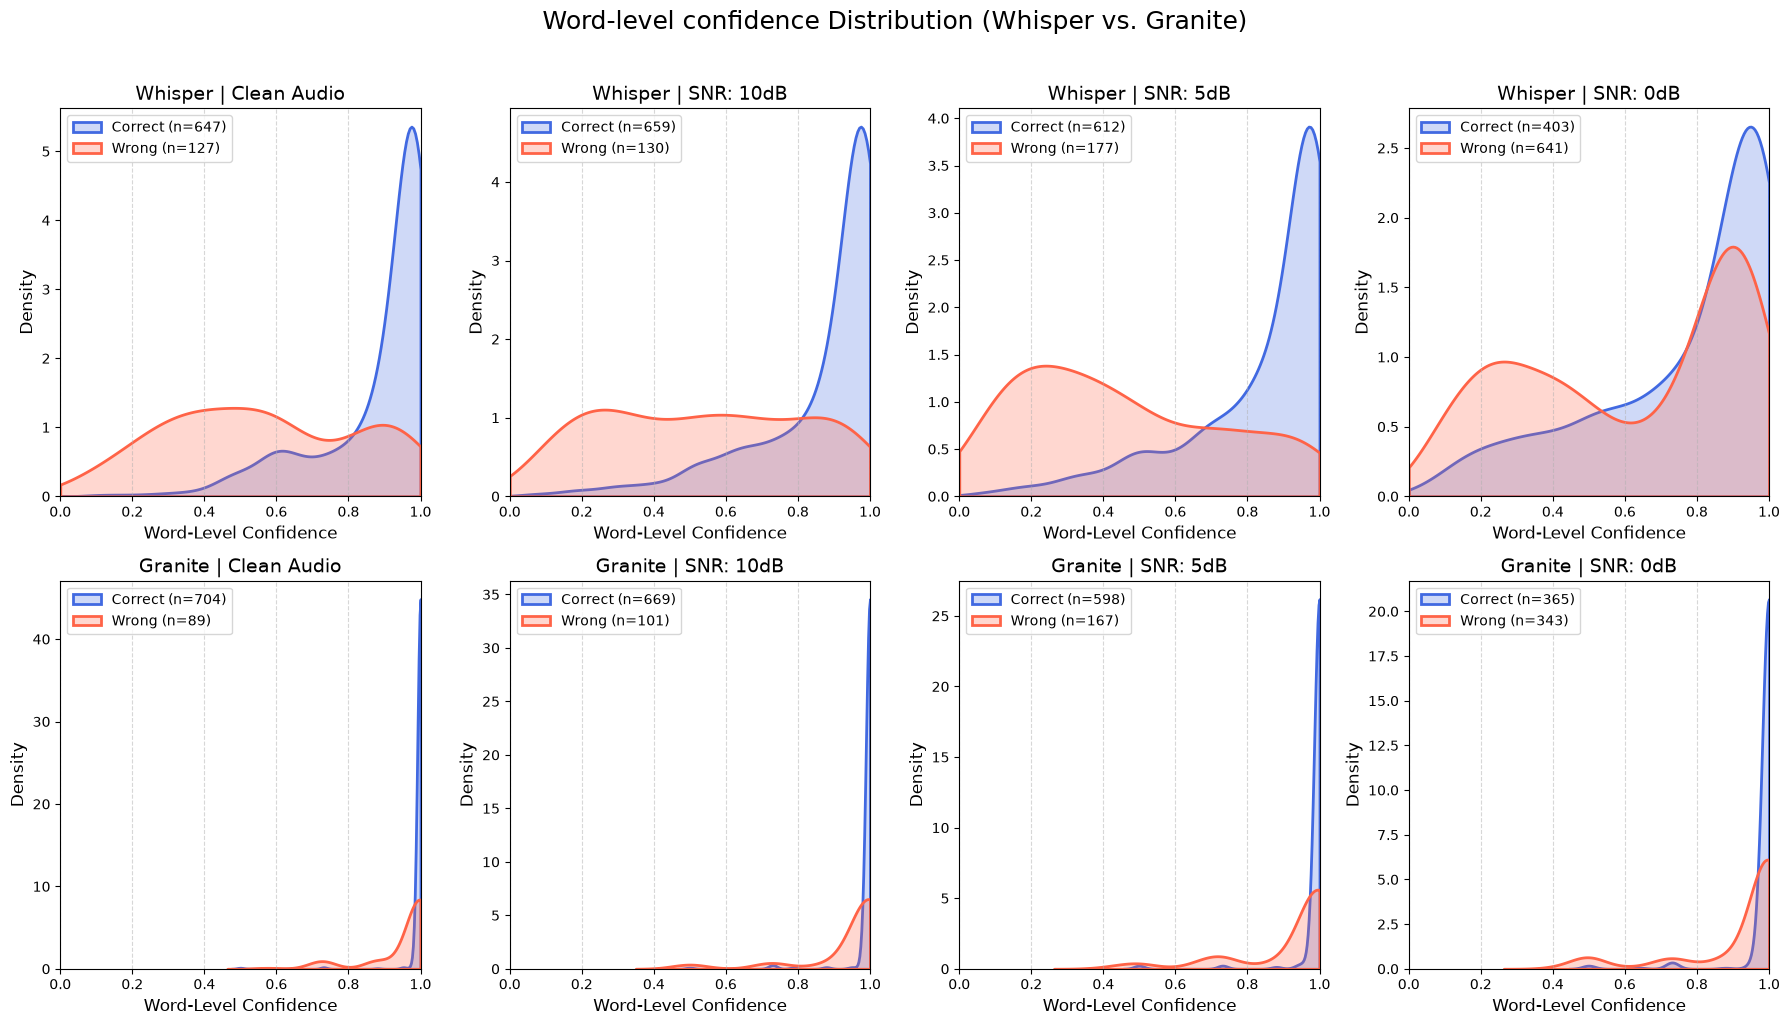

In [14]:
# 5. plot the confidence distribution

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Word-level confidence Distribution (Whisper vs. Granite)', fontsize=18, y=1.02)

models = ["whisper", "granite"]
# models = ["granite"]

for row_idx, model_name in enumerate(models):
    for col_idx, snr in enumerate(snr_levels):
        ax = axes[row_idx, col_idx]

        # split confidences and labels into their own array
        confidences = np.array([score for score, _ in results[model_name][snr]])
        labels = np.array([label for _, label in results[model_name][snr]])

        correct_conf = confidences[labels == 1]
        wrong_conf = confidences[labels == 0]

        assert(len(correct_conf) > 1)
        assert(len(wrong_conf) > 1)

        sns.kdeplot(
            correct_conf,
            fill=True,
            color="royalblue",
            label=f"Correct (n={len(correct_conf)})",
            ax=ax,
            clip=(0.0, 1.0),
            linewidth=2
        )
        sns.kdeplot(
            wrong_conf,
            fill=True,
            color="tomato",
            label=f"Wrong (n={len(wrong_conf)})",
            ax=ax,
            clip=(0.0, 1.0),
            linewidth=2
        )

        title = f"{model_name.capitalize()} | " + ("Clean Audio" if snr == "clean" else f"SNR: {snr}dB")
        ax.set_title(title, fontsize=14)
        ax.set_xlabel("Word-Level Confidence", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.set_xlim(0.0, 1.0)
        ax.grid(axis="x", linestyle="--", alpha=0.5)

        ax.legend(loc="upper left")

plt.tight_layout()
plt.show()